## Lab 1: Choose a sound and analyze it
In this lab you will choose a sound to be used for all the labs and start imitating it with a single sinusoid.

In [8]:
import numpy as np
from util import load_audio, save_audio, plot_signals
from IPython.display import Audio

**Example signal**

As an example of what you will do in the labs let's ear a sound similar to the one you will use in class and a synthesized version of it.

In [9]:
reference, fs = load_audio('audio/reference.wav')
Audio(reference, rate=fs)

**Synthesis**

Now we can load and listen to a synthesised signal like the one you will obtain by the end of the course and that tries to imitate the example signal. This is an audio signal created from scratch only using the knowledge gained during the course.

In [10]:
synthesis, fs = load_audio('audio/synthesis.wav')
Audio(synthesis, rate=fs)

### 1. Choose a reference sound

1.1. Find a recording of a single plucked string sound. Be creative, do not choose “guitar” by default, nor copy a sound from another group. You should use [Freesound](https://freesound.org/) to find the recordings (Freesound is a huge collaborative database of audio snippets released under Creative Commons licenses created and maintained by researchers of the Music Technology Group of the UPF). Try to find a sound with the best possible quality. The ideal sound format should be: uncompress (such as.wav, .aiff, but no .mp3), mono (one channel) and with a sampling rate of  44100Hz. The sound file should also contain a single note. You can start by downloading a sound from freesound and modify it with Audacity to the right format and content.

Write your answer here. Include the Freesound link to the selected sound recording.

1.2. Create your own github repository and upload your edited audio file there:

1) Sing up to github using your UPF gmail account: https://github.com/

2) Create a repository called **sis1_name** for your own work 

3) Upload your edited audio file to the repository

You will use that repository later in the lab, so keep your own audio file there even if you run the notebook with the bundled fallback first.


1.3. Clone your own repository and load the audio file from it. To keep the notebook runnable before you have your own recording, the code below also includes a fallback to the bundled reference sound in `audio/`. For the actual lab work, replace the fallback path with the audio file from your own repository.

In [11]:
from pathlib import Path

# Clone your own repository and point filepath to your own audio file.
# !git clone https://github.com/your-username/sis1_name.git
# filepath = Path('./sis1_name/your_file.wav')

filepath = None
try:
    # If you have your own file in a cloned repository, uncomment and edit the line below.
    filepath = Path('audio/my_sound.wav')
    if filepath is None:
        raise FileNotFoundError
    ref, fs = load_audio(filepath)
    print(f'Using audio file: {filepath}')
except FileNotFoundError:
    filepath = Path('audio/reference.wav')
    ref, fs = load_audio(filepath)
    print(f'Using bundled reference audio: {filepath}')

Using audio file: audio\my_sound.wav


Note that `load_audio` function returns two variables: the audio signal (as a one dimensional array of floating point numbers), and the sampling rate (as a integer number). Now we can plot the audio signal:

In [12]:
plot_signals(ref, fs)

You can use the zoom in tool to see more details.

You can also use Audio widget to listen the audio signal:

In [13]:
Audio(ref, rate=fs)

### 2. Measure the signal period and fundamental frequency

2.1. Measure the period length, in seconds, and the fundamental frequency, in Hz, of the sound you choose. You can use Audacity to measure the period by zooming into a stable portion of the sound. Then compute its inverse to find the fundamental frequency. Find the closest musical note (note name) of the measured frequency (use google).

**ANSWER**

Period found: 0,002 s

Frequency: f = 1/T = 1/0,002 ~ 500Hz

This frequency corresponds to a B4 or Si4 which in reality has a frequency of 493,88Hz

2.2. Calculate the period from the frequency value using Python:


In [ ]:
import numpy as np
from scipy.io import wavfile

sample_rate, data = wavfile.read('audio/my_sound.wav')

f_0 = 500.0 
period = 1.0 / f_0

print(f"Fundamental frequency (f0): {f_0} Hz")
print(f"Period calculated (T): {period:.3f} s")

Fundamental frequency (f0): 500.0 Hz
Period calculated (T): 0.002 s


C:\Users\oquil\AppData\Local\Temp\ipykernel_13408\2930553889.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, data = wavfile.read('audio/my_sound.wav')


2.3. Plot three periods of the signal using the `plot_signals` function and selecting `t_start` and `t_end` arguments accordingly. Try to get the first periods of the audio signal but avoiding the attack section.

In [54]:
# Function parameters setup:
# Uses standard inputs (ref, fs, lines) with 'my_sound' as the target audio.
# The start boundary is set to t = 0.006 s to bypass the initial onset delay 
# (audio starts at t = 0.003 s) and capture a stable portion of the waveform.

plot_signals(ref, fs, period*3, period*6 , 'audio/my_sound.wav', 'lines')



2.4. Measure the period of the signal manually by identifying the begining and ending of a periodic cycle. Note that when you hover the mouse over one of the points in the plot, you can see the time and amplitude values. For instance, you can check the cross by zero.

From the waveform plot, the length of the second cycle was measured by identifying its zero-crossing points. The cycle initiates at $T_i \approx 0.0078\text{ s}$ and concludes at $T_f \approx 0.0098\text{ s}$.The signal period ($T_0$) is calculated as follows:$$T_0 = T_f - T_i = 0.0098\text{ s} - 0.0078\text{ s} = 0.0020\text{ s}$$Consequently, the estimated fundamental frequency ($f_0$) is:$$f_0 = \frac{1}{T_0} = \frac{1}{0.0020\text{ s}} = 500\text{ Hz}$$

2.5. Do the measured fundamental frequency you obtained and the frequency of the closest musical note coincide? If not, explain why.

($500\text{ Hz}$) doesn't exactly match the theoretical pitch of the closest note ($\text{B}_4 \approx 493.88\text{ Hz}$). This small difference happens mainly because of two reasons:

**Guitar Tuning:** Real instruments are rarely tuned to perfection. Small changes in string tension, temperature, or even how hard the string is pressed can shift the pitch slightly.

**Measurement Precision:** Measuring the period ($T$) visually introduces a small human error. Since the period is so short ($\sim 0.002\text{ s}$), missing the exact point by even a fraction of a millisecond changes the calculated frequency by several Hertz. Also, the audio is digital ($f_s = 44.1\text{ kHz}$), which means time is divided into steps of about $0.022\text{ ms}$, adding a tiny limit to how precise we can be

### 3. Generating a sinusoid

3.1. Create a sinusoid of the same duration than the reference signal and same frequency than the fundamental frequency. Plot it along with the audio signal of the reference recording. Plot the same time segment that 2.3. Note that the sampling rate should be the same for both signals. Try to find the values of Amplitude and initial Phase that make the two signal segments plotted to match as close as possible (do not attempt to imitate the whole signal). Matching the phase is a bit tricky.



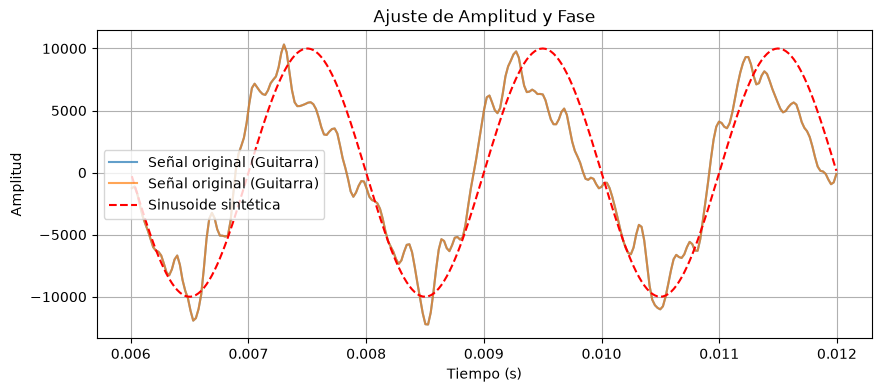

In [60]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate, my_sound = wavfile.read('audio/my_sound.wav')

duration = len(my_sound) / fs
t = np.linspace(0, duration, len(my_sound), endpoint=False)

f0 = 500.0       
A = 10000         
phi = -np.pi 

sinusoid = A * np.sin(2 * np.pi * f0 * t + phi)

t_start = 0.006  
t_end = 0.012   

mask = (t >= t_start) & (t <= t_end)

plt.figure(figsize=(10, 4))
plt.plot(t[mask], my_sound[mask], label="Señal original (Guitarra)", alpha=0.7)
plt.plot(t[mask], sinusoid[mask], label="Sinusoide sintética", linestyle="--", color="red")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Ajuste de Amplitud y Fase")
plt.legend()
plt.grid(True)
plt.show()

3.2. What are the main differences between the two signals.

Although both signals share the same fundamental pitch, they look quite different for a few clear reasons:

Wave Shape and Harmonics: The sine wave is completely pure and smooth. The guitar wave, on the other hand, looks "bumpy" because real instruments produce extra frequencies (harmonics) along with the main note. These extra peaks give the guitar its unique sound quality (timbre).

Changing Amplitude: The artificial wave stays perfectly bounded at a constant height. The guitar signal is dynamic, so its peaks naturally fluctuate slightly above and below the average level as the note rings out.

Real-world Noise: Unlike the clean mathematical sinusoid, the guitar recording carries small imperfections from background noise and the physical vibration of the string.


3.3. Save the synthesized signal using the 'save_audio` function:

In [59]:
save_audio('audio/my_sinusoid.wav', sinusoid, fs)